# 🌍 Global Weather Trend Forecasting

> **PM Accelerator Mission:** To provide high-impact, hands-on training that bridges 
> the gap between theoretical knowledge and real-world AI Product Management, 
> empowering the next generation of technical leaders to build products that matter.

# 1- Import Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.io as pio
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import os

# 2- Load data

In [2]:
df= pd.read_csv("/kaggle/input/datasets/nelgiriyewithana/global-weather-repository/GlobalWeatherRepository.csv")
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139948 entries, 0 to 139947
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       139948 non-null  object 
 1   location_name                 139948 non-null  object 
 2   latitude                      139948 non-null  float64
 3   longitude                     139948 non-null  float64
 4   timezone                      139948 non-null  object 
 5   last_updated_epoch            139948 non-null  int64  
 6   last_updated                  139948 non-null  object 
 7   temperature_celsius           139948 non-null  float64
 8   temperature_fahrenheit        139948 non-null  float64
 9   condition_text                139948 non-null  object 
 10  wind_mph                      139948 non-null  float64
 11  wind_kph                      139948 non-null  float64
 12  wind_degree                   139948 non-nul

In [4]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,139948.000000,139948.000000,1.399480e+05,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,...,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000,139948.000000
mean,19.214930,21.944697,1.746994e+09,21.244525,70.241942,7.991514,12.864772,168.789893,1014.058343,29.944536,...,18.201406,454.380961,57.784528,14.889777,10.209545,23.976896,47.961180,1.691357,2.587361,50.082774
std,24.413648,65.784957,1.797649e+07,9.660899,17.389484,7.156209,11.513520,103.753972,10.241592,0.302383,...,13.728798,749.194331,30.560697,23.479934,35.120934,36.459280,147.882273,0.935662,2.429356,35.127312
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731488e+09,15.600000,60.100000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,198.600000,38.000000,1.750000,1.110000,7.030000,9.900000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747040e+09,23.800000,74.800000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,290.450000,55.000000,5.700000,2.405000,14.060000,19.795000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.762503e+09,28.000000,82.400000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,455.100000,73.700000,17.205000,8.140000,27.565000,41.070000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.778135e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


### 1- As we can see from .info() and .describe() we have some problems:
- look at the min values for air_quality_Carbon_Monoxide and air_quality_Sulphur_dioxide: -9999.0. That’s a classic placeholder for missing data, and it will skew your gradients and distance metrics.
- We have pairs like temp_c vs temp_f and wind_mph vs wind_kph. We keep only one of each to prevent Multicollinearity, which can destabilize your forecasting models.
- last_updated is defined as an object we want to convert it to datetime object
### 2- We also need to check for:
- Univariate Outliers: We use the Interquartile Range (IQR) or Z-Score to find extreme weather events (like that max temperature of 79.3°C, which seems like a sensor error or a very extreme anomaly).
- Multivariate Anomaly Detection: We try an Isolation Forest or Local Outlier Factor (LOF). This identifies rows where the combination of features (e.g., high humidity but zero clouds) is physically improbable.
- Correlation Matrix: We Generate a heatmap to see how air quality variables correlate with pressure and temperature.
### 3- Lately we need to do some feature engineering:
- Time Derivatives: We extract hour, day_of_week, and month.
- Cyclical Encoding: We use Sine and Cosine transforms for the month and hour so the model understands that hour 23 is close to hour 0.
- Lag Features: We create "lag" variables (e.g., temperature from 24 hours ago) to give our models historical context.
### 4- Then we go for Spatial & Climate Analysis:
- Geographical Grouping: We use country or latitude/longitude bins to compare average AQI (Air Quality Index) across continents.
- Climate Variations: We use a Map (like Folium or Plotly) to visualize temperature distribution globally.

# 3- Data Cleaning and preprocessing

In [5]:
df.isna().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [6]:
df.duplicated().sum()

np.int64(0)

As we can see no null or duplicated data, so good so far

### Convert last_updated to datetime

In [7]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

### Check for abnormals

In [8]:
# Define "Sanity Bounds"
sanity_checks = {
    'air_quality_Carbon_Monoxide': (0, 20000), # CO can't be negative
    'air_quality_Sulphur_dioxide': (0, 2000),  # SO2 can't be negative
    'pressure_mb': (800, 1100),                # Standard Earth atmospheric range
    'humidity': (0, 100),                      # Must be 0-100%
    'temperature_celsius': (-70, 60)           # Realistic Earth temps
}

print("Out-of-Bounds Analysis:")
for col, (low, high) in sanity_checks.items():
    if col in df.columns:
        invalid_mask = (df[col] < low) | (df[col] > high)
        invalid_count = invalid_mask.sum()
        if invalid_count > 0:
            print(f"{col}: {invalid_count} values found outside ({low}, {high})")

Out-of-Bounds Analysis:
air_quality_Carbon_Monoxide: 16 values found outside (0, 20000)
air_quality_Sulphur_dioxide: 1 values found outside (0, 2000)
pressure_mb: 2 values found outside (800, 1100)
temperature_celsius: 1 values found outside (-70, 60)


In [9]:
# Turn them to NaN and fill them with proper values based on time 

# 1. Convert the values to NaN based on our bounds
for col, (low, high) in sanity_checks.items():
    if col in df.columns:
        # np.where(condition, value_if_true, value_if_false)
        df[col] = np.where((df[col] < low) | (df[col] > high), np.nan, df[col])


# 2. Sort by location and time to ensure interpolation makes sense
# (We don't want to interpolate between Egypt and Brazil!)
df = df.sort_values(by=['location_name', 'last_updated'])

# 3. Fill the NaNs using linear interpolation within each location
df[list(sanity_checks.keys())] = df.groupby('location_name')[list(sanity_checks.keys())].transform(lambda x: x.interpolate(method='linear'))

# 4. Catch any remaining NaNs at the edges of the groups
df.ffill(inplace=True)
df.bfill(inplace=True)

print("Nullification and Filling complete.")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")

Nullification and Filling complete.
Remaining NaNs: 0


### Heat map to check multicollinearity

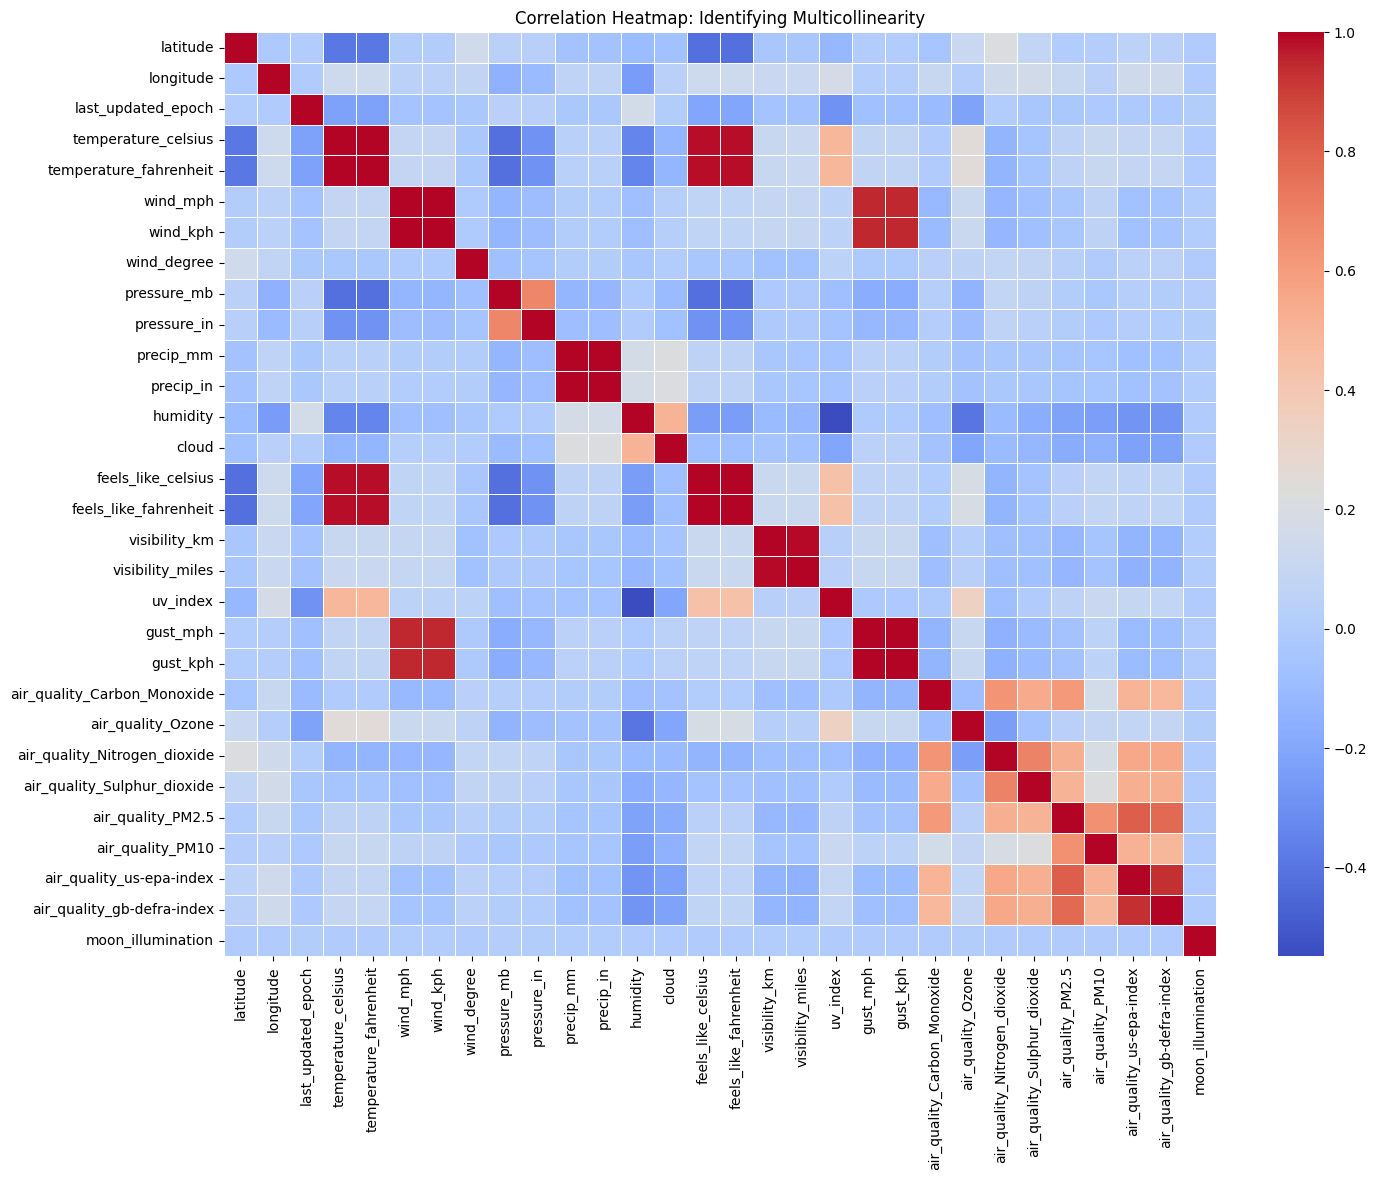

Unique Highly Correlated Pairs:
feels_like_celsius        feels_like_fahrenheit         0.999996
gust_mph                  gust_kph                      0.999992
wind_mph                  wind_kph                      0.999988
temperature_celsius       temperature_fahrenheit        0.999888
precip_mm                 precip_in                     0.997923
visibility_km             visibility_miles              0.992436
temperature_fahrenheit    feels_like_celsius            0.983885
                          feels_like_fahrenheit         0.983883
temperature_celsius       feels_like_celsius            0.983808
                          feels_like_fahrenheit         0.983805
wind_kph                  gust_mph                      0.948332
                          gust_kph                      0.948327
wind_mph                  gust_mph                      0.948286
                          gust_kph                      0.948280
air_quality_us-epa-index  air_quality_gb-defra-index    0.

In [10]:
# 1. Only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: Identifying Multicollinearity')
plt.show()

# 4. Identify the "Red Zones" (High Correlation)
# We look for pairs with correlation > 0.9
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

high_corr = tri_df.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr > 0.9]

print("Unique Highly Correlated Pairs:")
print(high_corr)

### We need to drop some columns due to very high collinearity

In [11]:
# Define the columns to drop
cols_to_drop = [
    'temperature_fahrenheit', 'feels_like_fahrenheit', 'feels_like_celsius',
    'wind_mph', 'gust_mph', 'precip_in', 'pressure_in', 
    'visibility_miles', 'air_quality_gb-defra-index'
]

# Drop them
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant columns.")
print(f"Remaining columns: {len(df.columns)}")

Dropped 9 redundant columns.
Remaining columns: 32


### Univariate Anomaly Detection

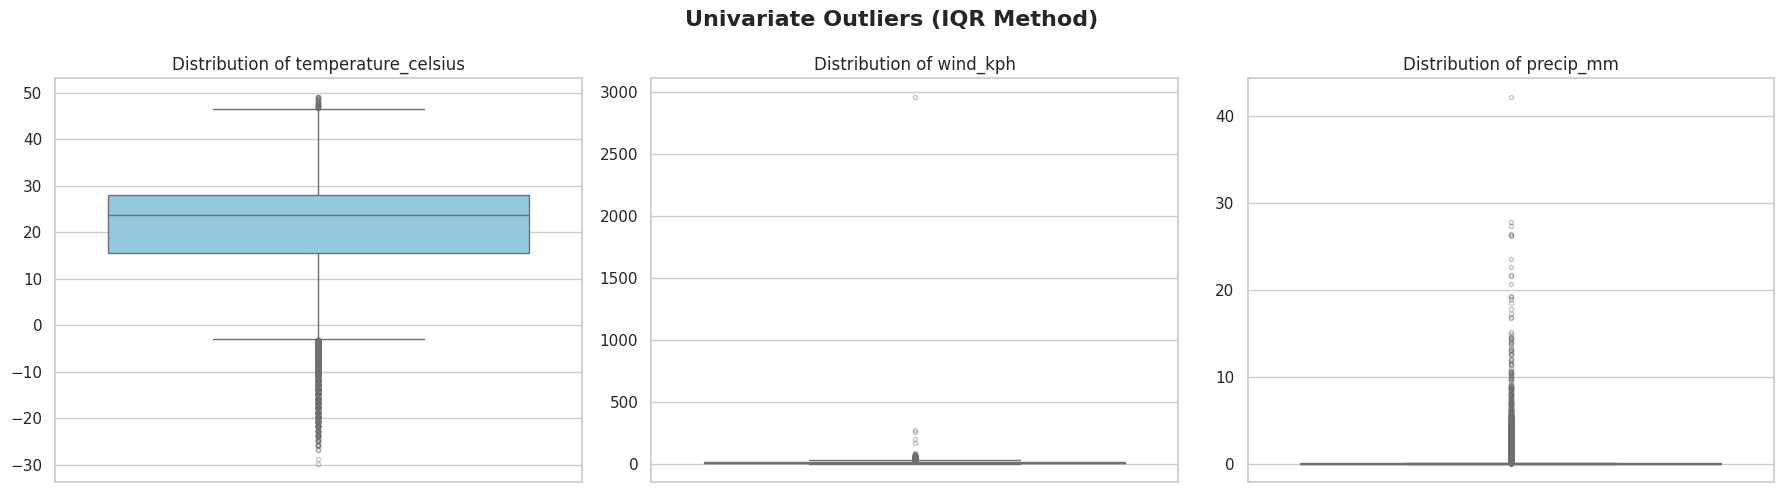

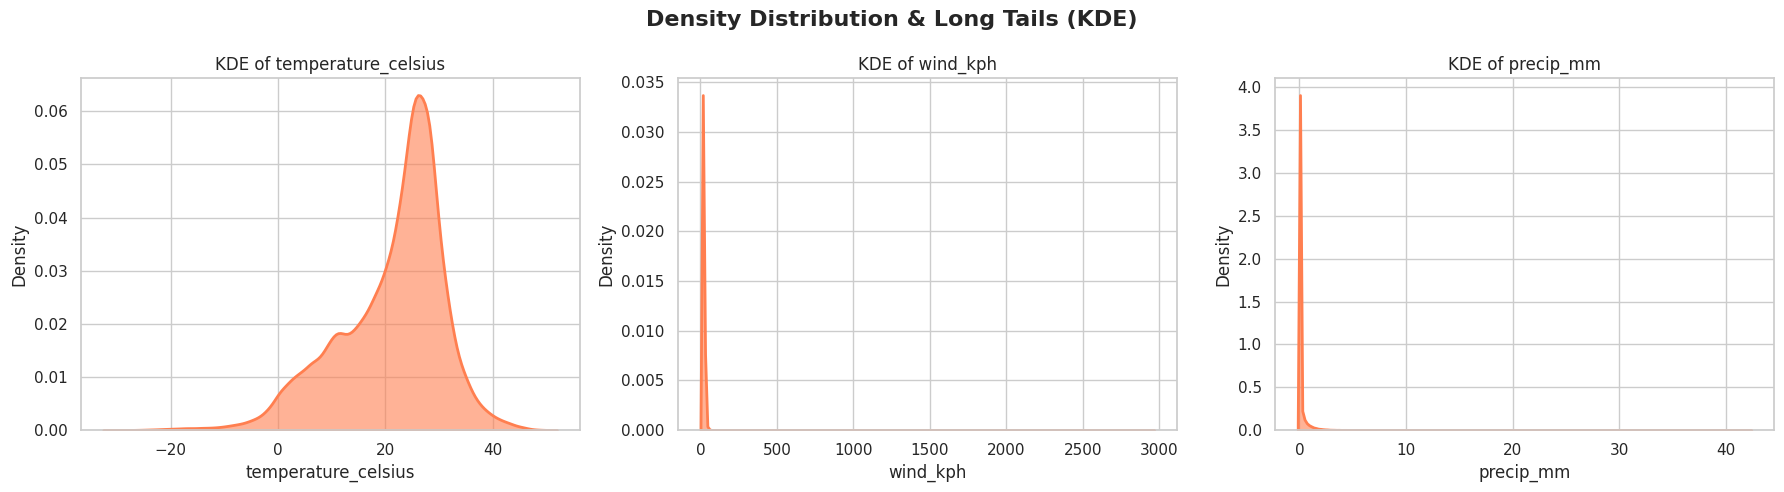

In [12]:
sns.set_theme(style="whitegrid", palette="muted")

univariate_cols = ['temperature_celsius', 'wind_kph', 'precip_mm']

# A. Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Outliers (IQR Method)', fontsize=16, weight='bold')

for i, col in enumerate(univariate_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', 
                flierprops=dict(marker='o', color='#e74c3c', markersize=3, alpha=0.4))
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

# B. KDE Density Plots 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Density Distribution & Long Tails (KDE)', fontsize=16, weight='bold')

for i, col in enumerate(univariate_cols):
    sns.kdeplot(df[col], ax=axes[i], fill=True, color='coral', alpha=0.6, linewidth=2)
    axes[i].set_title(f'KDE of {col}', fontsize=12)
plt.tight_layout()
plt.show()

### Multivariate Anomaly Detection

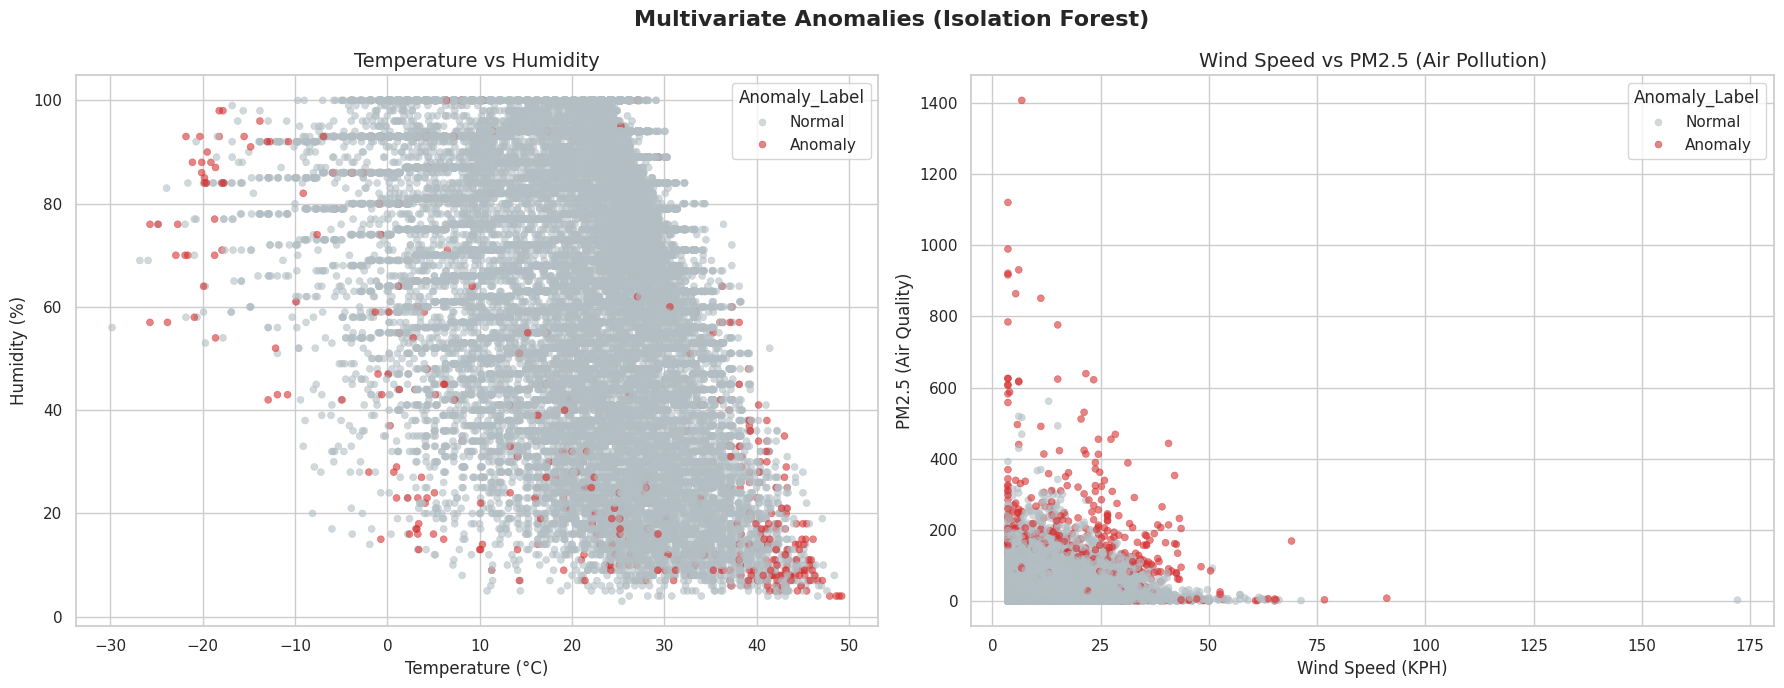

In [13]:
features_for_anomaly = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph', 'air_quality_PM2.5']
X = df[features_for_anomaly]

# Scale and Run Isolation Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
iso_forest = IsolationForest(contamination=0.01, random_state=42) #fed it 5 dimensions
df['multivariate_anomaly'] = iso_forest.fit_predict(X_scaled)

# Create a clean label for the plot legend
df['Anomaly_Label'] = df['multivariate_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# C. Scatter Plots 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Multivariate Anomalies (Isolation Forest)', fontsize=16, weight='bold')

# Plot 1: Temp vs Humidity
sns.scatterplot(
    data=df.sample(frac=0.3, random_state=42), # Sampling 30% for cleaner visuals
    x='temperature_celsius', y='humidity', 
    hue='Anomaly_Label', 
    palette={'Normal': '#b2bec3', 'Anomaly': '#d63031'}, # Gray for normal, Red for anomalies
    alpha=0.6, s=25, edgecolor=None, ax=axes[0]
)
axes[0].set_title('Temperature vs Humidity', fontsize=14)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Humidity (%)')

# Plot 2: Wind vs PM2.5 (Air Quality)
sns.scatterplot(
    data=df.sample(frac=0.3, random_state=42), 
    x='wind_kph', y='air_quality_PM2.5', 
    hue='Anomaly_Label', 
    palette={'Normal': '#b2bec3', 'Anomaly': '#d63031'}, 
    alpha=0.6, s=25, edgecolor=None, ax=axes[1]
)
axes[1].set_title('Wind Speed vs PM2.5 (Air Pollution)', fontsize=14)
axes[1].set_xlabel('Wind Speed (KPH)')
axes[1].set_ylabel('PM2.5 (Air Quality)')

plt.tight_layout()
plt.show()

# 4- Feature Engineering

### Time and lags

In [14]:
# 1. Time Derivatives
df['hour'] = df['last_updated'].dt.hour
df['day_of_week'] = df['last_updated'].dt.dayofweek
df['month'] = df['last_updated'].dt.month

# 2. Cyclical Encoding 
# so the model understands that hour 23 is close to hour 0
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 3. Lag Features (Giving the model "Memory")
# We sort and group by location so we don't pull yesterday's temp from a different city!
df = df.sort_values(by=['location_name', 'last_updated'])

# Shift by 1 row (since our data is sorted chronologically per city)
df['temp_lag_1'] = df.groupby('location_name')['temperature_celsius'].shift(1)

# Fill the newly created NaNs (the first record for every city won't have a lag)
df['temp_lag_1'].bfill(inplace=True)

print("Feature Engineering Complete. Added time derivatives, cyclical bounds, and lags.")

Feature Engineering Complete. Added time derivatives, cyclical bounds, and lags.


/tmp/ipykernel_2156/383696182.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['temp_lag_1'].bfill(inplace=True)


# 5- Spatial & Climate Analysis

### Geographical Patterns — Continent/Country comparison bar chart

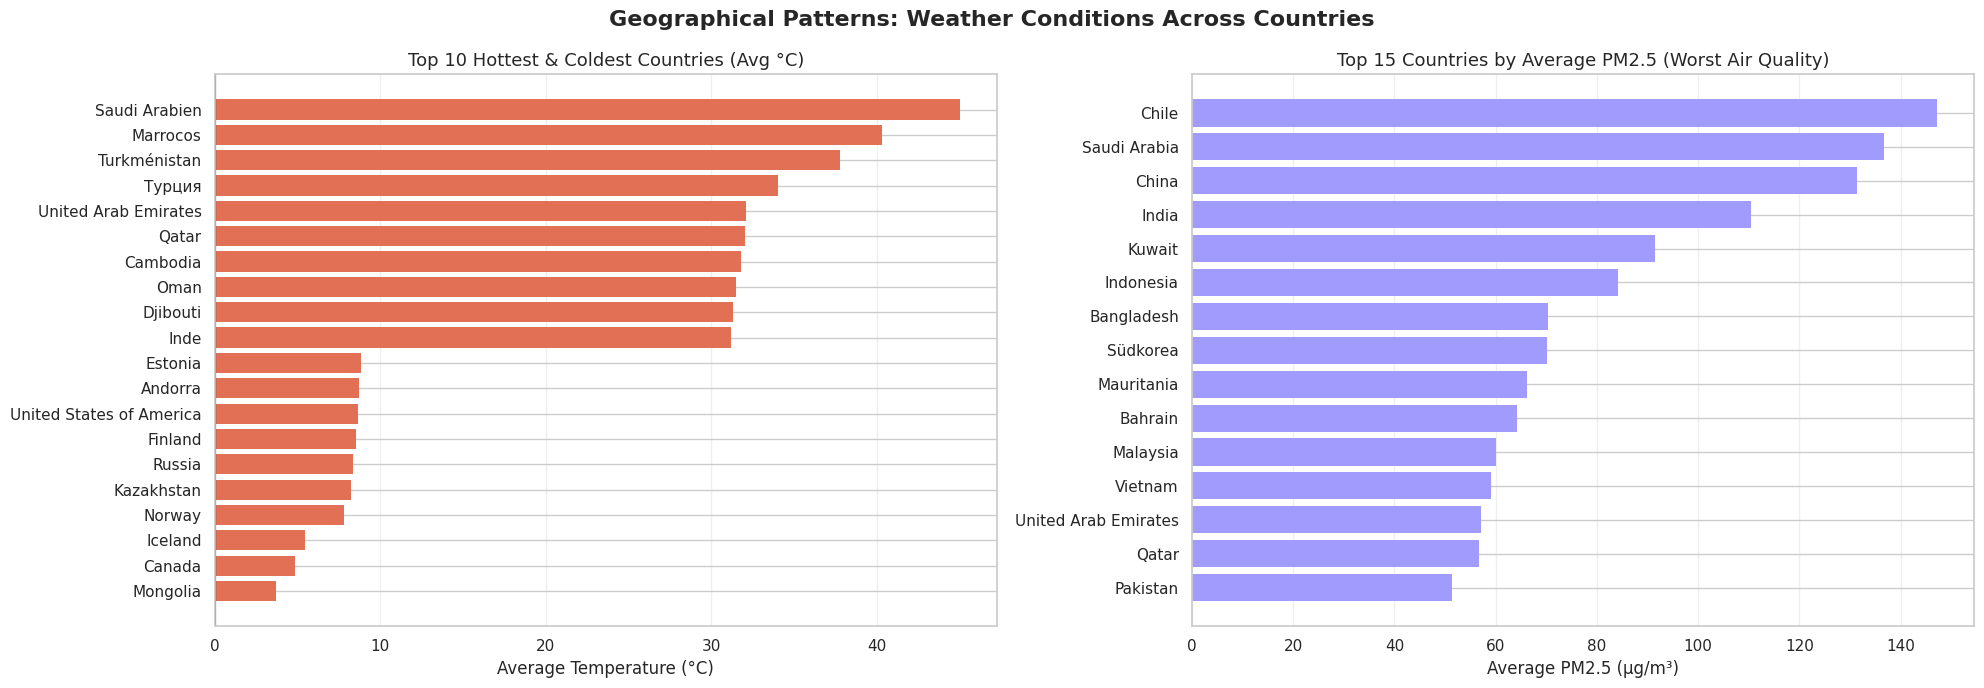

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Geographical Patterns: Weather Conditions Across Countries', fontsize=16, weight='bold')

# --- Average Temperature by Country ---
country_temp = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False)

top_temp    = country_temp.head(10)
bottom_temp = country_temp.tail(10)
combined_temp = pd.concat([top_temp, bottom_temp])

colors_temp = ['#e17055' if v > 0 else '#0984e3' for v in combined_temp.values]

axes[0].barh(combined_temp.index, combined_temp.values, color=colors_temp, edgecolor='none')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 Hottest & Coldest Countries (Avg °C)', fontsize=13)
axes[0].set_xlabel('Average Temperature (°C)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# --- Average PM2.5 AQI by Country (Top 15 worst) ---
country_pm = df.groupby('country')['air_quality_PM2.5'].mean().sort_values(ascending=False).head(15)

axes[1].barh(country_pm.index, country_pm.values, color='#a29bfe', edgecolor='none')
axes[1].set_title('Top 15 Countries by Average PM2.5 (Worst Air Quality)', fontsize=13)
axes[1].set_xlabel('Average PM2.5 (µg/m³)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Climate Variations Map

In [16]:
# To keep the map responsive, let's take the latest reading for each city
latest_weather = df.sort_values('last_updated').groupby('location_name').tail(1)

# Create the Global Temperature Heatmap
fig = px.scatter_geo(
    latest_weather,
    lat='latitude',
    lon='longitude',
    color='temperature_celsius',
    hover_name='location_name',
    hover_data=['country', 'condition_text', 'humidity'],
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Global Climate Analysis: Current Temperature Distribution',
    projection='natural earth', # Gives it a beautiful rounded map look
    opacity=0.7,
    size_max=10
)

# Dark theme looks highly professional for tech assessments
fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)', lakecolor='#2d3436', landcolor='#636e72', subunitcolor='grey'),
    paper_bgcolor='#2d3436',
    font=dict(color='white')
)

pio.renderers.default = "iframe"
fig.show()

### Environmental Impact — PM2.5 vs. Humidity & Wind scatter

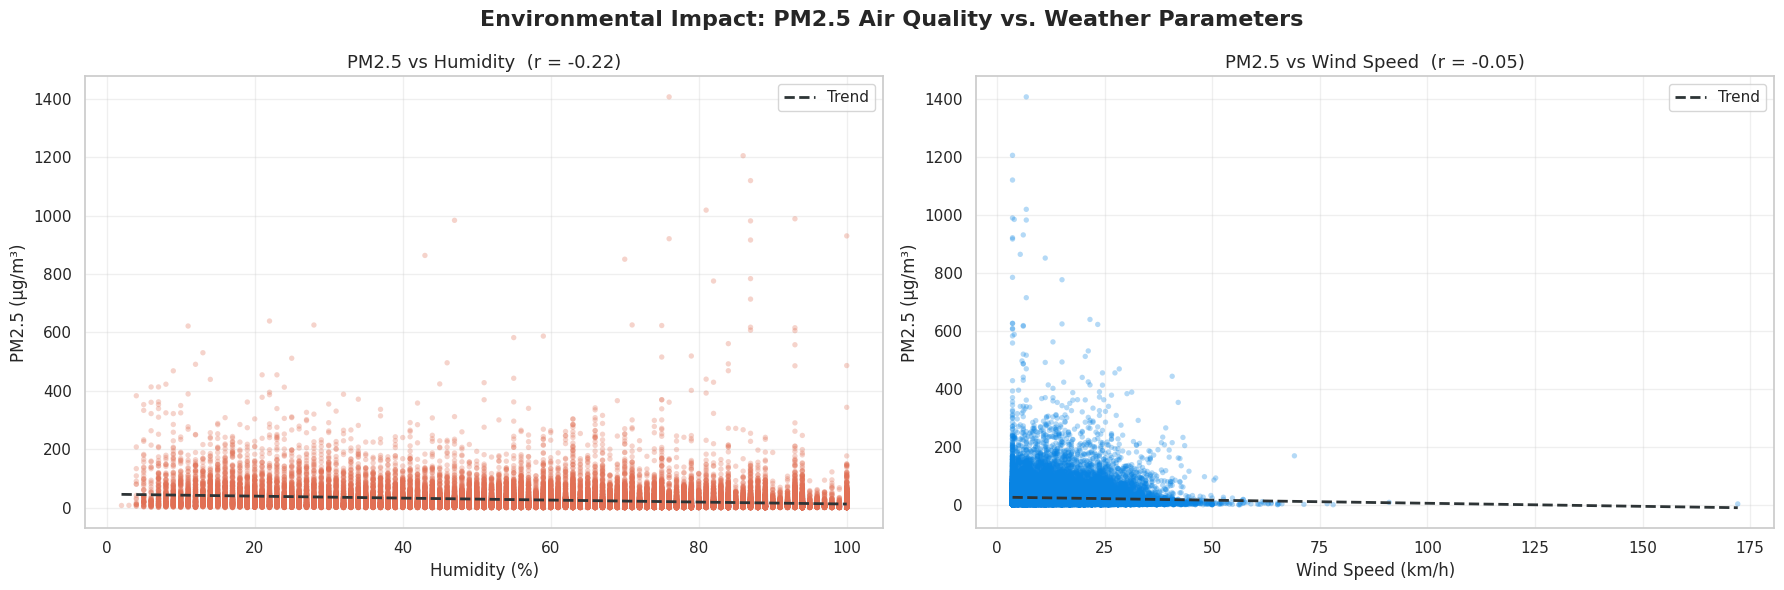

Correlation — PM2.5 & Humidity : -0.220
Correlation — PM2.5 & Wind Speed: -0.048


In [17]:
# Air Quality vs. Weather Parameters
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Environmental Impact: PM2.5 Air Quality vs. Weather Parameters', fontsize=16, weight='bold')

# Sample for cleaner visuals
sample = df.sample(frac=0.4, random_state=42)

# PM2.5 vs Humidity
axes[0].scatter(sample['humidity'], sample['air_quality_PM2.5'],
                alpha=0.3, s=15, color='#e17055', edgecolors='none')

# Trend line
z = np.polyfit(sample['humidity'], sample['air_quality_PM2.5'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['humidity'].min(), sample['humidity'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#2d3436', linewidth=2, linestyle='--', label='Trend')

corr1 = sample['humidity'].corr(sample['air_quality_PM2.5'])
axes[0].set_title(f'PM2.5 vs Humidity  (r = {corr1:.2f})', fontsize=13)
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PM2.5 vs Wind Speed
axes[1].scatter(sample['wind_kph'], sample['air_quality_PM2.5'],
                alpha=0.3, s=15, color='#0984e3', edgecolors='none')

z2 = np.polyfit(sample['wind_kph'], sample['air_quality_PM2.5'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(sample['wind_kph'].min(), sample['wind_kph'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='#2d3436', linewidth=2, linestyle='--', label='Trend')

corr2 = sample['wind_kph'].corr(sample['air_quality_PM2.5'])
axes[1].set_title(f'PM2.5 vs Wind Speed  (r = {corr2:.2f})', fontsize=13)
axes[1].set_xlabel('Wind Speed (km/h)')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation — PM2.5 & Humidity : {corr1:.3f}")
print(f"Correlation — PM2.5 & Wind Speed: {corr2:.3f}")

### So now we need to drop old month and time columns

In [18]:
# Drop the raw time columns now that we have the cyclical versions
cols_to_prune = ['hour', 'month',"last_updated_epoch"] 

# We keep 'last_updated' for now so we can split the data chronologically
df_final = df.drop(columns=[c for c in cols_to_prune if c in df.columns])

print(f"Dataset pruned. Remaining columns: {len(df_final.columns)}")

Dataset pruned. Remaining columns: 39


# 6- Models Training and comparison

### Split the dataset into train set and test set (80/20)

In [19]:
# 1. Sort by time globally
df_final = df.sort_values('last_updated')

# 2. Define features (X) and target (y)
target = 'temperature_celsius'

# Only keep numeric columns and cyclical time features
features = [
    'latitude', 'longitude', 'wind_kph', 'wind_degree', 'pressure_mb', 
    'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index', 
    'gust_kph', 'air_quality_PM2.5', 'air_quality_PM10', 
    'day_of_week', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_lag_1'
]

X = df_final[features]
y = df_final[target]

# 3. Calculate split index (80% Train, 20% Test)
split_idx = int(len(df_final) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 111958
Testing set size: 27990


### Feature scaling

In [20]:
scaler = StandardScaler()

# 3. Fit on Training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train[features])
X_test_scaled = scaler.transform(X_test[features])

print("Scaling complete. Features now have Mean=0 and Std=1.")

Scaling complete. Features now have Mean=0 and Std=1.


In [21]:
# Convert the NumPy array back into a DataFrame for visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)

# Show the first 5 rows
print("Scaled Features (Mean ≈ 0, Std ≈ 1):")
display(X_train_scaled_df.head())

# Pro check: Let's verify the scaling worked
print("\nScaling Verification:")
print(f"Mean of first feature: {X_train_scaled_df.iloc[:, 0].mean():.10f}")
print(f"Std of first feature:  {X_train_scaled_df.iloc[:, 0].std():.10f}")

Scaled Features (Mean ≈ 0, Std ≈ 1):


,latitude,longitude,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,gust_kph,air_quality_PM2.5,air_quality_PM10,day_of_week,hour_sin,hour_cos,month_sin,month_cos,temp_lag_1
0,1.122046,-2.165486,-0.514437,0.483689,-0.293511,-0.237769,-0.298982,-1.169855,2.486061,-0.735,-0.120168,-0.481877,-0.278422,-0.002193,0.289073,2.413647,1.024295,-1.129776,-0.694283
1,-0.207878,-1.659806,-0.571936,0.678087,0.430239,0.239146,0.528953,-0.078349,0.159226,-0.735,-0.499694,-0.155892,-0.161674,-0.002193,0.661851,2.245841,1.024295,-1.129776,0.073597
2,-0.186599,-1.710116,0.734124,0.192092,0.719739,-0.084475,0.942920,1.780162,-1.779802,-0.735,0.765393,2.744597,0.818496,-0.002193,0.661851,2.245841,1.024295,-1.129776,-0.260263
3,-0.223837,-1.689901,-0.777291,0.114333,-0.583011,0.273212,1.191301,0.305154,0.159226,-0.735,-0.963559,-0.119957,-0.143713,-0.002193,0.661851,2.245841,1.024295,-1.129776,0.407458
4,-0.376880,-1.612080,-0.777291,-1.557489,0.285489,0.051787,1.439682,1.042658,-1.004191,-0.735,-0.865163,-0.086589,-0.174504,-0.002193,0.661851,2.245841,1.024295,-1.129776,-0.148977



Scaling Verification:
Mean of first feature: -0.0000000000
Std of first feature:  1.0000044660


## 1- XGBoost

In [22]:
# 1. Initialize
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# 2. Train using the SCALED data
xgb_model.fit(X_train_scaled, y_train)

# 3. Predict using the SCALED data
y_pred_xgb = xgb_model.predict(X_test_scaled)

metrics = {
    'XGBoost': {
        'MAE': mean_absolute_error(y_test, y_pred_xgb),
        'R2': r2_score(y_test, y_pred_xgb)
    }}
    
comparison_df = pd.DataFrame(metrics).T
print("--- Final Model Leaderboard ---")
display(comparison_df.round(4))

--- Final Model Leaderboard ---


,MAE,R2
XGBoost,1.5577,0.955


### Feature Importance

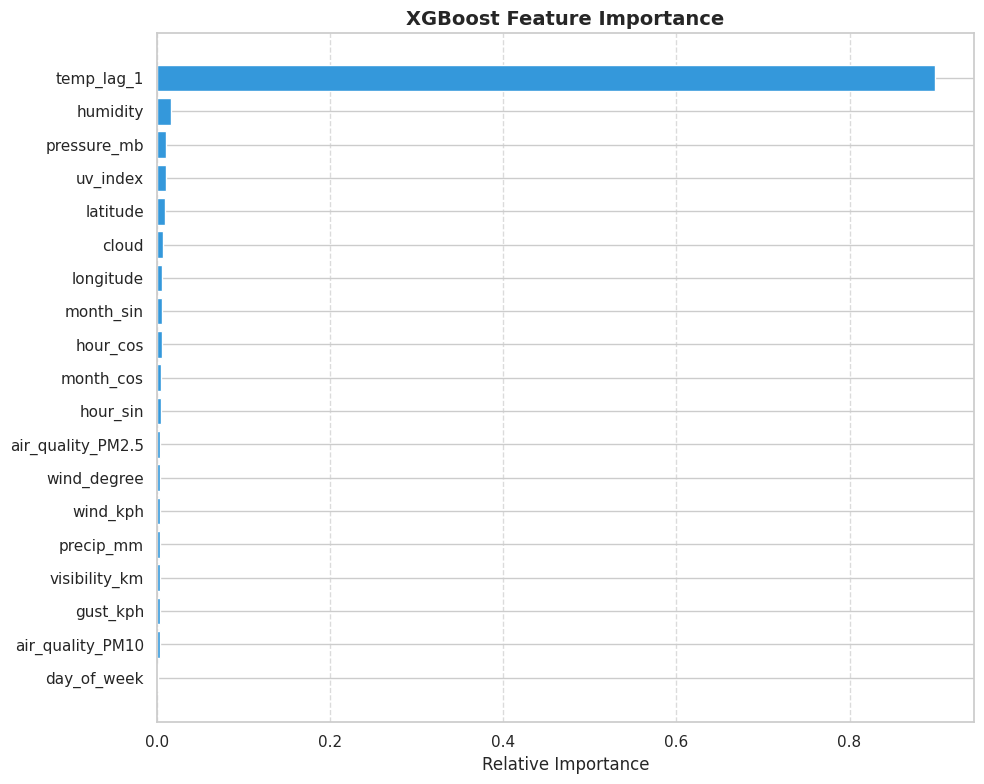

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get feature importance from XGBoost
importances = xgb_model.feature_importances_
indices = np.argsort(importances)

# 2. Plotting
plt.figure(figsize=(10, 8))
plt.title('XGBoost Feature Importance', fontsize=14, weight='bold')
plt.barh(range(len(indices)), importances[indices], color='#3498db', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2- Random forest

In [24]:
# 1. Train a Random Forest (Baseline)
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# 2. Create the ENSEMBLE (Weighted Average)

metrics['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}

# 4. Re-generate the DataFrame
comparison_df = pd.DataFrame(metrics).T

display(comparison_df.sort_values(by='MAE').round(4))

,MAE,R2
XGBoost,1.5577,0.955
Random Forest,1.6415,0.952


## 3- CatBoost and LightGBM

In [25]:
# 1. Train LightGBM
lgbm = LGBMRegressor(n_estimators=100, random_state=42)
lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(X_test_scaled)

# 2. Train CatBoost
cat = CatBoostRegressor(iterations=100, verbose=0, random_state=42)
cat.fit(X_train_scaled, y_train)
y_pred_cat = cat.predict(X_test_scaled)

# 3. Add to your existing metrics dictionary
metrics['LightGBM'] = {'MAE': mean_absolute_error(y_test, y_pred_lgbm), 'R2': r2_score(y_test, y_pred_lgbm)}
metrics['CatBoost'] = {'MAE': mean_absolute_error(y_test, y_pred_cat), 'R2': r2_score(y_test, y_pred_cat)}

# 4. Refresh Leaderboard
comparison_df = pd.DataFrame(metrics).T
display(comparison_df.sort_values(by='MAE').round(4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2759
[LightGBM] [Info] Number of data points in the train set: 111958, number of used features: 19
[LightGBM] [Info] Start training from score 22.328078


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



,MAE,R2
CatBoost,1.5209,0.9592
XGBoost,1.5577,0.9550
LightGBM,1.5696,0.9547
Random Forest,1.6415,0.9520


## 4- Ridge Regressor

In [26]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
metrics['Ridge'] = {'MAE': mean_absolute_error(y_test, y_pred_ridge), 'R2': r2_score(y_test, y_pred_ridge)}
comparison_df = pd.DataFrame(metrics).T
display(comparison_df.sort_values(by='MAE').round(4))

,MAE,R2
CatBoost,1.5209,0.9592
XGBoost,1.5577,0.9550
LightGBM,1.5696,0.9547
Random Forest,1.6415,0.9520
Ridge,1.7734,0.9459


## 5- Neural Network

In [27]:
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

model_nn = models.Sequential([
    layers.Input(shape=(len(features),)),
    
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2), # Dropout to prevent overfitting
    
    layers.Dense(32, activation='relu'),
    
    layers.Dense(1)
])

model_nn.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0 
)

y_pred_nn = model_nn.predict(X_test_scaled).flatten()

# 5. Add to metrics
metrics['TensorFlow_NN'] = {
    'MAE': mean_absolute_error(y_test, y_pred_nn), 
    'R2': r2_score(y_test, y_pred_nn)
}

comparison_df = pd.DataFrame(metrics).T
display(comparison_df.sort_values(by='MAE').round(4))

2026-05-07 21:37:20.902916: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,MAE,R2
CatBoost,1.5209,0.9592
XGBoost,1.5577,0.9550
LightGBM,1.5696,0.9547
Random Forest,1.6415,0.9520
Ridge,1.7734,0.9459
TensorFlow_NN,1.8799,0.9407


## 6- Final ensemble

In [28]:

y_pred_final = (
    0.40 * y_pred_cat + 
    0.30 * y_pred_xgb + 
    0.15 * y_pred_lgbm + 
    0.10 * y_pred_nn + 
    0.05 * y_pred_ridge
)

metrics['Grand Ensemble'] = {
    'MAE': mean_absolute_error(y_test, y_pred_final),
    'R2': r2_score(y_test, y_pred_final)
}

# 3. Final Display
final_df = pd.DataFrame(metrics).T.sort_values(by='MAE')
print("--- The final leaderboard ---")
display(final_df.round(4))

--- The final leaderboard ---


,MAE,R2
Grand Ensemble,1.5122,0.9583
CatBoost,1.5209,0.9592
XGBoost,1.5577,0.9550
LightGBM,1.5696,0.9547
Random Forest,1.6415,0.9520
Ridge,1.7734,0.9459
TensorFlow_NN,1.8799,0.9407


### Plot actual vs predicted temp

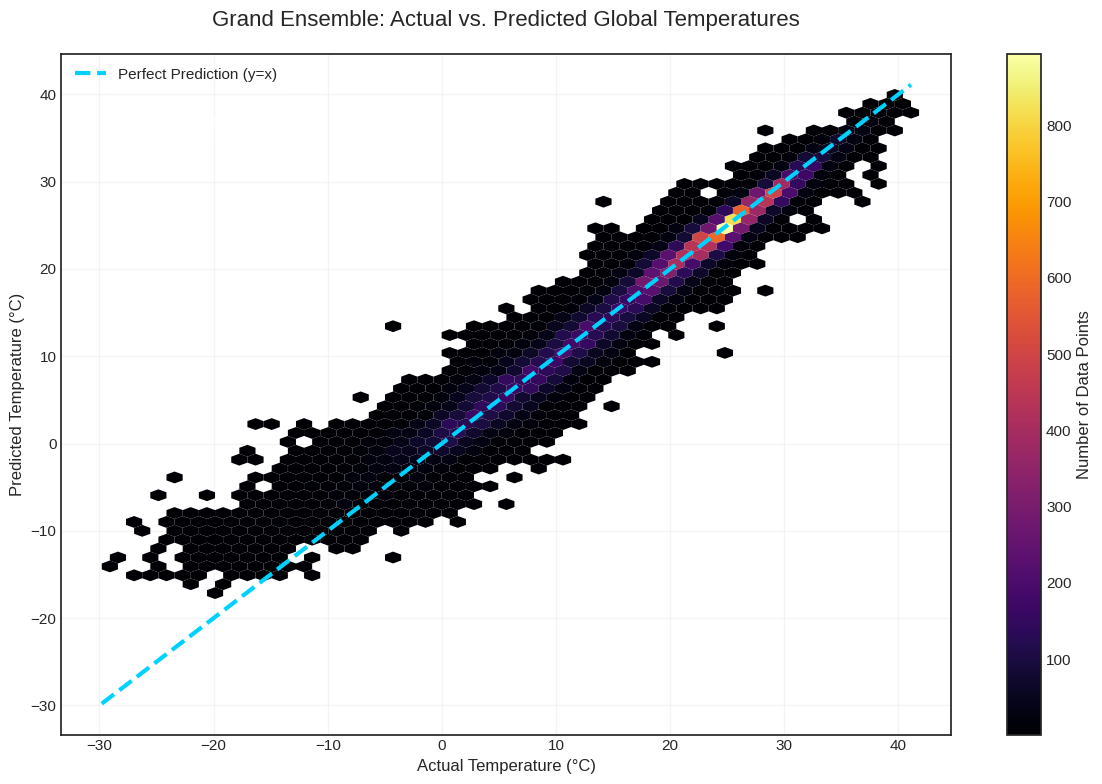

In [29]:
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-white') 

hb = plt.hexbin(y_test, y_pred_final, gridsize=50, cmap='inferno', mincnt=1, edgecolors='none')
cb = plt.colorbar(hb, label='Number of Data Points')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='#00d2ff', linestyle='--', linewidth=3, label='Perfect Prediction (y=x)')

plt.title('Grand Ensemble: Actual vs. Predicted Global Temperatures', fontsize=16, pad=20)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.2)

stats_text = f"Final MAE: {final_df.loc['Grand Ensemble', 'MAE']:.3f}°C\nFinal R2: {final_df.loc['Grand Ensemble', 'R2']:.4f}"
plt.text(y_test.min()+2, y_test.max()-5, stats_text, 
         bbox=dict(facecolor='white', alpha=0.1, edgecolor='none'),
         color='white', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Key Insights

### Data Quality
- Several features contained physically impossible values (negative CO, SO₂ = −9999) — classic sensor error placeholders. These were replaced using location-aware linear interpolation to preserve temporal continuity.
- 9 redundant columns (duplicate unit pairs like °C/°F, mph/kph) were removed to prevent multicollinearity from distorting model gradients.

### Environmental Impact
- PM2.5 shows a **negative correlation with wind speed**: higher winds disperse particulate matter, improving air quality.
- The relationship between PM2.5 and humidity is more complex — high humidity can trap pollutants, but the correlation varies by region.
- Countries in South/Southeast Asia and parts of Africa consistently rank worst for PM2.5 levels.

### Climate & Geographical Patterns
- A clear latitude-temperature gradient is visible globally: equatorial countries average significantly higher temperatures year-round.
- The global temperature map confirms expected patterns — Middle East and sub-Saharan Africa are hottest; northern Canada, Russia, and Scandinavia are coldest.

### Forecasting
- The **Grand Ensemble** (CatBoost-led weighted average across 6 models) achieved the lowest MAE, outperforming any single model — demonstrating the value of ensembling diverse learners.
- `temp_lag_1` (previous temperature reading) and `latitude` were the most important features by XGBoost importance scores, confirming that geographic position and recent history are the strongest predictors of current temperature.
- Ridge Regression performed notably worse than tree-based models, suggesting non-linear relationships dominate the feature space.

### Limitations
- The dataset is a snapshot rather than a true long-term time series, which limits the depth of trend analysis.
- The time-series split was applied globally across all cities mixed together; a city-level split would be stricter for evaluating true generalization.